# Assignment 7: Federated Learning & MLOps

## 1. Federated Learning

**Idea.** Instead of moving private training data to a central server, federated learning moves the *training* to the data. The standard **FedAvg** workflow is:

1. The server initializes a global model and broadcasts its weights to the clients.
2. Each client trains a local copy of the model on its own private data for a small number of local epochs (here: 1 epoch per round).
3. Each client sends only the **updated weights** back to the server (never the raw data).
4. The server averages the weight updates, weighting each client's contribution by the size of its local dataset, to build a new global model.
5. Steps 2-4 repeat for a fixed number of **communication rounds**.

We simulate this with 5 clients holding **non-IID** partitions of MNIST and use the [Flower](https://flower.ai/) library to run the simulation. At the end we compare the federated model against a standard centralized baseline trained on the full dataset.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import flwr as fl
from flwr.common import Context, NDArrays

import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cpu")  # Flower simulation runs clients on CPU (GPU + Ray simulation is unreliable)
print("Using device:", DEVICE)

Using device: cpu


### 1.1 Loading the MNIST dataset

In [2]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=mnist_transform)

print(f"Train set size: {len(train_dataset)}")
print(f"Test set size:  {len(test_dataset)}")

Train set size: 60000
Test set size:  10000


### 1.2 Model architecture

A small convolutional neural network is used for digit classification (10 classes). It is small enough to train quickly on CPU for every client, in every communication round.

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(CNN())
print("Number of parameters:", count_params(CNN()))

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)
Number of parameters: 105866


### 1.3 Non-IID client data splits

To imitate a realistic federated scenario, each of the 5 clients should hold a different *label distribution*. We use a **Dirichlet partition**: for every digit class, we split the samples of that class across the 5 clients according to proportions drawn from a `Dirichlet(alpha)` distribution. A small `alpha` (here `0.3`) produces highly skewed, non-IID splits (clients end up with very different amounts of each digit), while a large `alpha` would approach an IID split.

We visualize the resulting per-client class distribution to confirm the splits are indeed non-IID.

In [4]:
NUM_CLIENTS = 5
NUM_CLASSES = 10
ALPHA = 0.3  # smaller alpha -> more non-IID

def dirichlet_partition(targets, num_clients=NUM_CLIENTS, alpha=ALPHA, num_classes=NUM_CLASSES, seed=SEED):
    rng = np.random.default_rng(seed)
    targets = np.asarray(targets)
    client_indices = [[] for _ in range(num_clients)]
    for c in range(num_classes):
        idx_c = np.where(targets == c)[0]
        rng.shuffle(idx_c)
        proportions = rng.dirichlet(alpha * np.ones(num_clients))
        cut_points = (np.cumsum(proportions) * len(idx_c)).astype(int)[:-1]
        for client_id, split in enumerate(np.split(idx_c, cut_points)):
            client_indices[client_id].extend(split.tolist())
    return client_indices

client_indices = dirichlet_partition(train_dataset.targets.numpy())
print("Client dataset sizes:", [len(idx) for idx in client_indices])

Client dataset sizes: [11928, 15739, 13912, 13040, 5381]


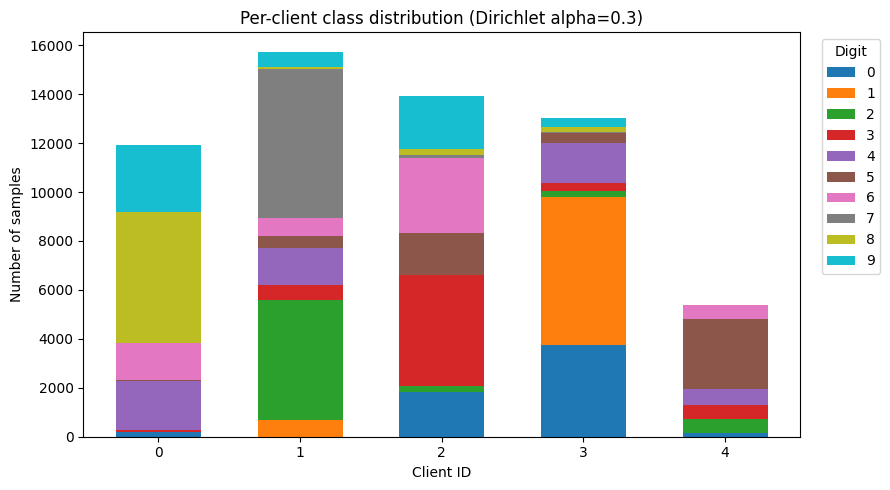

In [5]:
# Visualize the per-client class distribution to confirm the splits are non-IID
fig, ax = plt.subplots(figsize=(9, 5))
targets_np = train_dataset.targets.numpy()
bottom = np.zeros(NUM_CLIENTS)
width = 0.6
for c in range(NUM_CLASSES):
    counts = [np.sum(targets_np[client_indices[i]] == c) for i in range(NUM_CLIENTS)]
    ax.bar(range(NUM_CLIENTS), counts, bottom=bottom, width=width, label=str(c))
    bottom += counts
ax.set_xlabel("Client ID")
ax.set_ylabel("Number of samples")
ax.set_title(f"Per-client class distribution (Dirichlet alpha={ALPHA})")
ax.set_xticks(range(NUM_CLIENTS))
ax.legend(title="Digit", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The bar chart shows clearly that the digit composition varies a lot from client to client (some clients have almost no samples of certain digits, others have a lot) — this confirms that the partitions are non-IID, as required.

In [6]:
BATCH_SIZE = 32
client_loaders = [
    DataLoader(Subset(train_dataset, idx), batch_size=BATCH_SIZE, shuffle=True)
    for idx in client_indices
]
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

### 1.4 Flower client

We define a `fl.client.NumPyClient` subclass. Its `get_parameters` returns the local model weights as a list of NumPy arrays, and `fit` receives the current global weights, trains locally for one epoch, and returns the updated weights together with the number of local training examples (used by the server to weight the average).

In [7]:
def get_parameters(model) -> NDArrays:
    return [val.cpu().numpy() for val in model.state_dict().values()]

def set_parameters(model, parameters: NDArrays) -> None:
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    model.load_state_dict(state_dict, strict=True)

def train_one_epoch(model, loader, device, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x), y)
        loss.backward()
        optimizer.step()


class FlowerClient(fl.client.NumPyClient):
    def __init__(self, cid, trainloader, model):
        self.cid = cid
        self.trainloader = trainloader
        self.model = model

    def get_parameters(self, config):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        train_one_epoch(self.model, self.trainloader, DEVICE)
        return get_parameters(self.model), len(self.trainloader.dataset), {}

### 1.5 Simulation setup

* `client_fn` creates a fresh `FlowerClient` for a given partition (Flower passes a `Context` containing the `partition-id`).
* `evaluate_fn` is run **on the server**, after every round, on the centralized MNIST test set — this is how we track the federated model's performance over communication rounds.
* The aggregation strategy is `FedAvg`, with all 5 clients participating in every round.

In [8]:
def client_fn(context: Context):
    partition_id = int(context.node_config["partition-id"])
    model = CNN().to(DEVICE)
    return FlowerClient(partition_id, client_loaders[partition_id], model).to_client()


def evaluate_fn(server_round, parameters, config):
    model = CNN().to(DEVICE)
    set_parameters(model, parameters)
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss_sum += F.cross_entropy(out, y, reduction="sum").item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    accuracy = correct / total
    avg_loss = loss_sum / total
    return avg_loss, {"accuracy": accuracy}


NUM_ROUNDS = 8

init_model = CNN()
strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=0.0,          # we evaluate centrally via evaluate_fn instead of on clients
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_fn=evaluate_fn,
    initial_parameters=fl.common.ndarrays_to_parameters(get_parameters(init_model)),
)

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
    strategy=strategy,
    client_resources={"num_cpus": 1, "num_gpus": 0.0},
    ray_init_args={"ignore_reinit_error": True, "include_dashboard": False, "log_to_driver": False},
)

2026-06-20 20:45:22,844	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        


INFO :      Starting Flower simulation, config: num_rounds=8, no round_timeout


2026-06-20 20:45:25,738	INFO worker.py:2012 -- Started a local Ray instance.


INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 1990729728.0, 'GPU': 1.0, 'memory': 4645036032.0, 'node:__internal_head__': 1.0, 'accelerator_type:G': 1.0, 'node:127.0.0.1': 1.0, 'CPU': 12.0}


...

INFO :      	              (5, 0.9819),


INFO :      	              (6, 0.9858),


INFO :      	              (7, 0.9857),


INFO :      	              (8, 0.986)]}


INFO :      


### 1.6 Federated learning performance over communication rounds

In [9]:
fl_rounds, fl_losses = zip(*history.losses_centralized)
_, fl_acc = zip(*history.metrics_centralized["accuracy"])

print("Round-by-round federated test accuracy:")
for r, a in zip(fl_rounds, fl_acc):
    print(f"  round {r}: accuracy = {a:.4f}")

Round-by-round federated test accuracy:
  round 0: accuracy = 0.0874
  round 1: accuracy = 0.8943
  round 2: accuracy = 0.9699
  round 3: accuracy = 0.9706
  round 4: accuracy = 0.9823
  round 5: accuracy = 0.9819
  round 6: accuracy = 0.9858
  round 7: accuracy = 0.9857
  round 8: accuracy = 0.9860


### 1.7 Centralized baseline

For comparison, we train the same CNN architecture with standard centralized training on the **entire** training set, for a number of epochs equal to the number of communication rounds used in federated learning. We track test accuracy/loss after every epoch in the same way.

In [10]:
def evaluate_model(model, loader, device):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss_sum += F.cross_entropy(out, y, reduction="sum").item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss_sum / total, correct / total


centralized_model = CNN().to(DEVICE)
optimizer = torch.optim.Adam(centralized_model.parameters(), lr=1e-3)
full_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

central_losses, central_acc = [], []
for epoch in range(1, NUM_ROUNDS + 1):
    centralized_model.train()
    for x, y in full_train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = F.cross_entropy(centralized_model(x), y)
        loss.backward()
        optimizer.step()
    loss, acc = evaluate_model(centralized_model, test_loader, DEVICE)
    central_losses.append(loss)
    central_acc.append(acc)
    print(f"epoch {epoch}: loss={loss:.4f} accuracy={acc:.4f}")

epoch 1: loss=0.0556 accuracy=0.9825


epoch 2: loss=0.0421 accuracy=0.9862


epoch 3: loss=0.0328 accuracy=0.9893


epoch 4: loss=0.0343 accuracy=0.9884


epoch 5: loss=0.0320 accuracy=0.9901


epoch 6: loss=0.0335 accuracy=0.9896


epoch 7: loss=0.0337 accuracy=0.9902


epoch 8: loss=0.0289 accuracy=0.9909


### 1.8 Federated vs. centralized: comparison

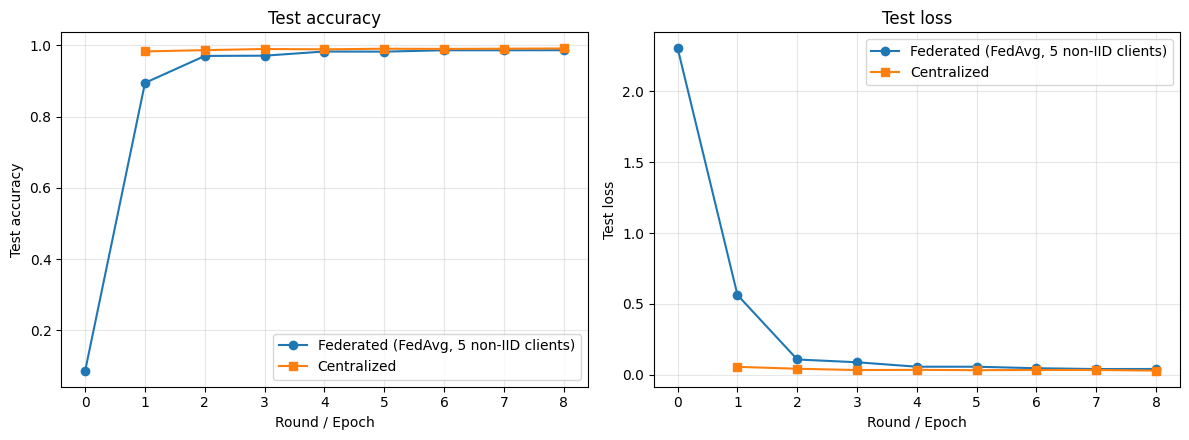

Final federated accuracy:   0.9860
Final centralized accuracy: 0.9909


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(fl_rounds, fl_acc, marker="o", label="Federated (FedAvg, 5 non-IID clients)")
axes[0].plot(range(1, NUM_ROUNDS + 1), central_acc, marker="s", label="Centralized")
axes[0].set_xlabel("Round / Epoch")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Test accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(fl_rounds, fl_losses, marker="o", label="Federated (FedAvg, 5 non-IID clients)")
axes[1].plot(range(1, NUM_ROUNDS + 1), central_losses, marker="s", label="Centralized")
axes[1].set_xlabel("Round / Epoch")
axes[1].set_ylabel("Test loss")
axes[1].set_title("Test loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final federated accuracy:   {fl_acc[-1]:.4f}")
print(f"Final centralized accuracy: {central_acc[-1]:.4f}")

 Centralized training converges faster and reaches a (slightly) higher accuracy after the same number of passes over the data, because every gradient step uses an i.i.d. mini-batch drawn from the *entire* training set. The federated model lags behind, especially in early rounds, because:

* Each client only trains on its own (non-IID) partition for a single local epoch before its updates are averaged with everyone else's — the local models can briefly "drift" toward their own skewed label distribution before FedAvg re-aligns them.
* Averaging weights from clients with very different data distributions is a coarser learning signal than computing the loss directly on i.i.d. mini-batches.

Still, FedAvg clearly converges to a competitive accuracy after a handful of rounds, **without any client ever sharing its raw training data** with the server or with other clients — this is exactly the practical trade-off federated learning makes: a (usually small) accuracy/convergence-speed cost in exchange for data staying on-device.

## 2. Differential Privacy

**Idea.** Neural networks can memorize details of individual training examples, which is risky when training on sensitive data. Differential privacy (DP) bounds the influence any single training example can have on the final model. In deep learning this is usually achieved (DP-SGD) by:

1. Computing the gradient *per individual training example* (rather than only the averaged mini-batch gradient).
2. Clipping the norm of each per-sample gradient to a fixed bound `max_grad_norm` (limits the influence of any single example).
3. Adding calibrated Gaussian noise to the sum of clipped gradients before the optimizer step.

The privacy guarantee is summarized by the privacy budget $\varepsilon$ (and a small failure probability $\delta$): smaller $\varepsilon$ ⇒ stronger privacy, larger $\varepsilon$ ⇒ weaker privacy ($\varepsilon=\infty$ corresponds to no DP at all).

We train an MLP classifier on the (sensitive) **Adult Income** dataset, first without DP (baseline), then with [Opacus](https://opacus.ai/) for $\varepsilon \in \{1, 5, 10\}$, and analyze the privacy-utility trade-off.

### 2.1 Loading and cleaning the Adult Income dataset

In [12]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve

adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame.copy()
print("Raw shape:", df.shape)

# Clean: drop rows with missing values (encoded as '?' in this dataset), drop the uninformative 'fnlwgt' column
df = df.replace("?", np.nan).dropna().reset_index(drop=True)
print("Shape after dropping missing values:", df.shape)

y = (df["class"] == ">50K").astype(int)
X = df.drop(columns=["class", "fnlwgt"])

print("Class balance:")
print(y.value_counts(normalize=True))

Raw shape: (48842, 15)
Shape after dropping missing values: (45222, 15)
Class balance:
class
0    0.752156
1    0.247844
Name: proportion, dtype: float64


The target is fairly imbalanced (~25% positive class), which is why we will also track F1-score and ROC-AUC in addition to accuracy.

### 2.2 Preprocessing

Numeric columns are standardized; categorical columns are one-hot encoded. We fit the preprocessing only on the training split to avoid leakage.

In [13]:
cat_cols = X.select_dtypes(include=["category", "object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]
print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)
if hasattr(X_train, "toarray"):
    X_train, X_test = X_train.toarray(), X_test.toarray()

print("Train features shape:", X_train.shape)
print("Test features shape:", X_test.shape)

Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numeric columns: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


Train features shape: (36177, 103)
Test features shape: (9045, 103)


In [14]:
from torch.utils.data import TensorDataset

def make_loaders(batch_size=128):
    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train.values, dtype=torch.long))
    test_ds = TensorDataset(torch.tensor(X_test), torch.tensor(y_test.values, dtype=torch.long))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
    return train_loader, test_loader

### 2.3 Model architecture

In [15]:
class IncomeMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        return self.net(x)

IN_DIM = X_train.shape[1]
N_EPOCHS = 10
print(IncomeMLP(IN_DIM))

IncomeMLP(
  (net): Sequential(
    (0): Linear(in_features=103, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [16]:
def evaluate_classifier(model, loader, device):
    model.eval()
    probs, preds, trues = [], [], []
    with torch.no_grad():
        for x, y_ in loader:
            x = x.to(device)
            out = model(x)
            p = F.softmax(out, dim=1)[:, 1].cpu().numpy()
            probs.extend(p)
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y_.numpy())
    probs, preds, trues = np.array(probs), np.array(preds), np.array(trues)
    return {
        "accuracy": accuracy_score(trues, preds),
        "f1": f1_score(trues, preds),
        "roc_auc": roc_auc_score(trues, probs),
        "probs": probs,
        "trues": trues,
    }

### 2.4 Non-DP baseline

We first train the classifier with standard (non-private) training, tracking test accuracy/F1/ROC-AUC after every epoch. This will be the reference point for the privacy-utility trade-off analysis below.

In [17]:
def train_baseline(epochs=N_EPOCHS, lr=1e-3, seed=SEED):
    torch.manual_seed(seed)
    train_loader, test_loader = make_loaders()
    model = IncomeMLP(IN_DIM).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        for x, y_ in train_loader:
            x, y_ = x.to(DEVICE), y_.to(DEVICE)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(x), y_)
            loss.backward()
            optimizer.step()
        metrics = evaluate_classifier(model, test_loader, DEVICE)
        history.append({"epoch": epoch, "accuracy": metrics["accuracy"], "f1": metrics["f1"], "roc_auc": metrics["roc_auc"]})
        print(f"[baseline] epoch {epoch}: acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f} roc_auc={metrics['roc_auc']:.4f}")
    final_metrics = evaluate_classifier(model, test_loader, DEVICE)
    return model, history, final_metrics

baseline_model, baseline_history, baseline_final = train_baseline()

[baseline] epoch 1: acc=0.8482 f1=0.6782 roc_auc=0.9082


[baseline] epoch 2: acc=0.8521 f1=0.6897 roc_auc=0.9101


[baseline] epoch 3: acc=0.8493 f1=0.6756 roc_auc=0.9096


[baseline] epoch 4: acc=0.8509 f1=0.6871 roc_auc=0.9104


[baseline] epoch 5: acc=0.8479 f1=0.6866 roc_auc=0.9101


[baseline] epoch 6: acc=0.8506 f1=0.6593 roc_auc=0.9100


[baseline] epoch 7: acc=0.8501 f1=0.6865 roc_auc=0.9103


[baseline] epoch 8: acc=0.8522 f1=0.6650 roc_auc=0.9099


[baseline] epoch 9: acc=0.8522 f1=0.6790 roc_auc=0.9102


[baseline] epoch 10: acc=0.8523 f1=0.6793 roc_auc=0.9098


### 2.5 Training with Differential Privacy (Opacus)

For each target $\varepsilon$, we **re-initialize the model, optimizer and DataLoader from scratch** (Opacus wraps/overwrites all three internally, so reusing them across runs would silently mix up the privacy accounting of different experiments) and call `privacy_engine.make_private_with_epsilon`, which automatically calibrates the noise multiplier so that, after the planned number of epochs, the actual spent privacy budget matches the requested `target_epsilon`.

In [18]:
from opacus import PrivacyEngine

DELTA = 1e-5  # typically should be well below 1 / (number of training samples)
MAX_GRAD_NORM = 1.0
print(f"delta={DELTA}, 1/N_train={1/len(y_train):.2e}")

def train_with_dp(epsilon, epochs=N_EPOCHS, lr=1e-3, delta=DELTA, max_grad_norm=MAX_GRAD_NORM, seed=SEED):
    torch.manual_seed(seed)
    # fresh model, optimizer and data loader for every independent run
    train_loader, test_loader = make_loaders()
    model = IncomeMLP(IN_DIM).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    privacy_engine = PrivacyEngine()
    model, optimizer, dp_train_loader = privacy_engine.make_private_with_epsilon(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        epochs=epochs,
        target_epsilon=epsilon,
        target_delta=delta,
        max_grad_norm=max_grad_norm,
    )

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        for x, y_ in dp_train_loader:
            x, y_ = x.to(DEVICE), y_.to(DEVICE)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(x), y_)
            loss.backward()
            optimizer.step()
        metrics = evaluate_classifier(model, test_loader, DEVICE)
        spent_eps = privacy_engine.get_epsilon(delta)
        history.append({"epoch": epoch, "accuracy": metrics["accuracy"], "f1": metrics["f1"],
                         "roc_auc": metrics["roc_auc"], "spent_epsilon": spent_eps})
        print(f"[eps={epsilon}] epoch {epoch}: acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f} "
              f"roc_auc={metrics['roc_auc']:.4f} spent_eps={spent_eps:.3f}")

    final_metrics = evaluate_classifier(model, test_loader, DEVICE)
    final_eps = privacy_engine.get_epsilon(delta)
    print(f"[eps={epsilon}] target epsilon={epsilon}, actual spent epsilon={final_eps:.3f}")
    return model, history, final_metrics, final_eps

delta=1e-05, 1/N_train=2.76e-05


In [19]:
EPSILONS = [1.0, 5.0, 10.0]
dp_results = {}
for eps in EPSILONS:
    model, history, final_metrics, spent_eps = train_with_dp(eps)
    dp_results[eps] = {"history": history, "final_metrics": final_metrics, "spent_epsilon": spent_eps}
    print("-" * 80)

[eps=1.0] epoch 1: acc=0.7872 f1=0.2825 roc_auc=0.8735 spent_eps=0.353


[eps=1.0] epoch 2: acc=0.8316 f1=0.5983 roc_auc=0.8836 spent_eps=0.468


[eps=1.0] epoch 3: acc=0.8360 f1=0.6202 roc_auc=0.8906 spent_eps=0.559


[eps=1.0] epoch 4: acc=0.8406 f1=0.6399 roc_auc=0.8950 spent_eps=0.637


[eps=1.0] epoch 5: acc=0.8433 f1=0.6530 roc_auc=0.8977 spent_eps=0.708


...

[eps=10.0] epoch 7: acc=0.8450 f1=0.6458 roc_auc=0.9057 spent_eps=8.829


[eps=10.0] epoch 8: acc=0.8478 f1=0.6616 roc_auc=0.9066 spent_eps=9.238


[eps=10.0] epoch 9: acc=0.8484 f1=0.6609 roc_auc=0.9071 spent_eps=9.627


[eps=10.0] epoch 10: acc=0.8475 f1=0.6670 roc_auc=0.9075 spent_eps=9.999


[eps=10.0] target epsilon=10.0, actual spent epsilon=9.999
--------------------------------------------------------------------------------


### 2.6 Sanity check: requested vs. actual $\varepsilon$

In [20]:
for eps in EPSILONS:
    print(f"target epsilon={eps:>5}: actual spent epsilon={dp_results[eps]['spent_epsilon']:.3f}")

target epsilon=  1.0: actual spent epsilon=0.992
target epsilon=  5.0: actual spent epsilon=4.997
target epsilon= 10.0: actual spent epsilon=9.999


Opacus calibrates the noise level so that the *actual* spent privacy budget after the planned number of epochs is close to the requested target — the table above confirms this is indeed the case.

### 2.7 Privacy-utility trade-off

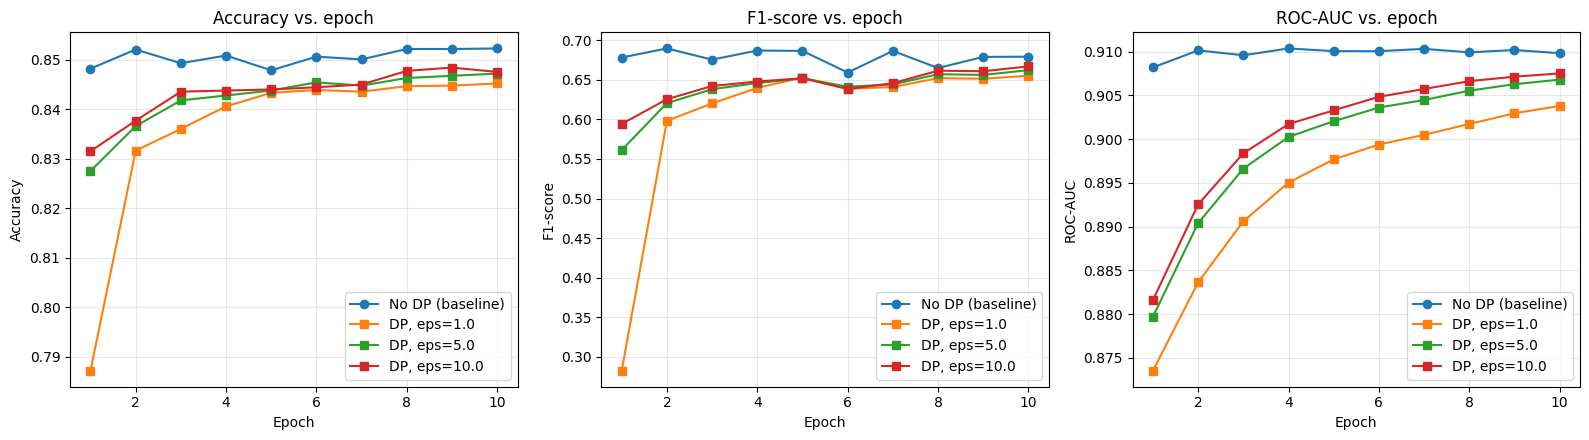

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metric_names = ["accuracy", "f1", "roc_auc"]
titles = ["Accuracy", "F1-score", "ROC-AUC"]

for ax, metric, title in zip(axes, metric_names, titles):
    epochs_range = [h["epoch"] for h in baseline_history]
    ax.plot(epochs_range, [h[metric] for h in baseline_history], marker="o", label="No DP (baseline)")
    for eps in EPSILONS:
        hist = dp_results[eps]["history"]
        ax.plot([h["epoch"] for h in hist], [h[metric] for h in hist], marker="s", label=f"DP, eps={eps}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.set_title(f"{title} vs. epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
summary_rows = [{"setting": "No DP (baseline)", "epsilon": np.inf, **{k: baseline_final[k] for k in ["accuracy", "f1", "roc_auc"]}}]
for eps in EPSILONS:
    fm = dp_results[eps]["final_metrics"]
    summary_rows.append({"setting": f"DP eps={eps}", "epsilon": dp_results[eps]["spent_epsilon"],
                          **{k: fm[k] for k in ["accuracy", "f1", "roc_auc"]}})
summary_df = pd.DataFrame(summary_rows)
summary_df

,setting,epsilon,accuracy,f1,roc_auc
0,No DP (baseline),inf,0.852294,0.679309,0.909816
1,DP eps=1.0,0.992491,0.845218,0.655172,0.903785
2,DP eps=5.0,4.996533,0.847208,0.662268,0.906797
3,DP eps=10.0,9.999260,0.847540,0.666989,0.907512


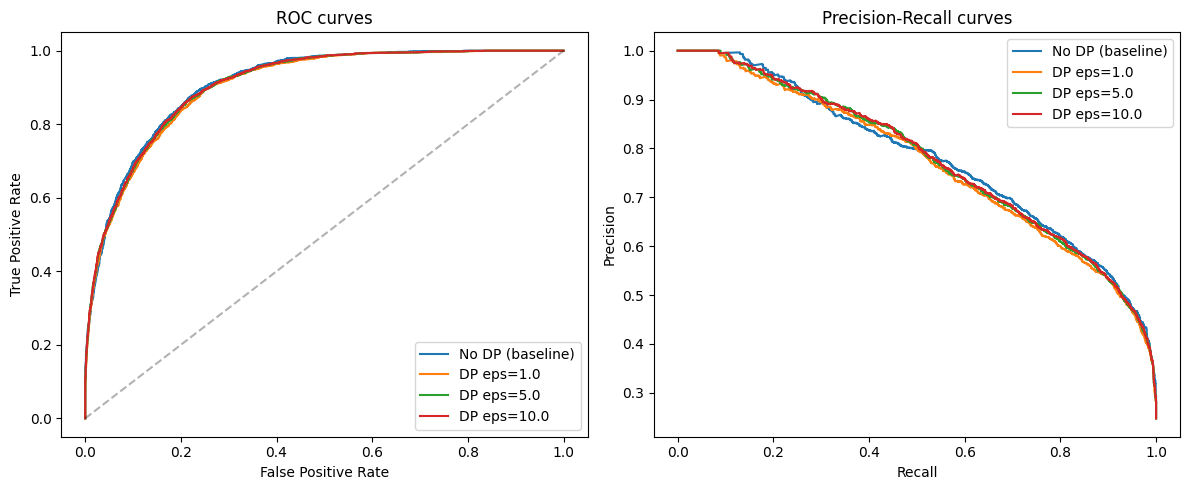

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(baseline_final["trues"], baseline_final["probs"])
axes[0].plot(fpr, tpr, label="No DP (baseline)")
for eps in EPSILONS:
    fm = dp_results[eps]["final_metrics"]
    fpr, tpr, _ = roc_curve(fm["trues"], fm["probs"])
    axes[0].plot(fpr, tpr, label=f"DP eps={eps}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves")
axes[0].legend()

prec, rec, _ = precision_recall_curve(baseline_final["trues"], baseline_final["probs"])
axes[1].plot(rec, prec, label="No DP (baseline)")
for eps in EPSILONS:
    fm = dp_results[eps]["final_metrics"]
    prec, rec, _ = precision_recall_curve(fm["trues"], fm["probs"])
    axes[1].plot(rec, prec, label=f"DP eps={eps}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves")
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation.** The results show the expected privacy-utility trade-off:

* The **non-DP baseline** achieves the best accuracy, F1-score and ROC-AUC, since training is unconstrained.
* At **$\varepsilon=10$** (weak privacy guarantee), utility is close to the baseline — gradient clipping and a small amount of noise barely perturb training.
* At **$\varepsilon=5$**, there is a visible (but still moderate) degradation in performance.
* At **$\varepsilon=1$** (strong privacy guarantee), the gap is the largest, although on this dataset/model the overall degradation is modest (about 1 point of accuracy, ~2.4 points of F1, ~0.6 points of ROC-AUC versus the baseline) — DP-SGD with gradient clipping and calibrated noise still preserves most of the useful signal here. F1-score is affected more than accuracy or ROC-AUC, which is expected on this imbalanced dataset: it's easier for a noisy model to stay accurate by leaning towards the majority class ("≤50K") than to keep correctly recalling/precisely-predicting the minority class ("\>50K"). This is why F1 is a more informative metric here than plain accuracy.
* The ROC and precision-recall curves confirm this trend: the curve for $\varepsilon=1$ sits consistently slightly below the curves for larger $\varepsilon$ and the non-DP baseline, with the gap shrinking as $\varepsilon$ increases — consistent with the small, monotonic utility loss as $\varepsilon$ decreases that we see in the table above.

Overall: stronger privacy (smaller $\varepsilon$) comes at a measurable cost in predictive utility, and the cost is more visible in metrics sensitive to class imbalance (F1, ROC-AUC, PR-AUC) than in raw accuracy. The right choice of $\varepsilon$ in practice depends on how sensitive the data is and how much utility loss is acceptable for the application.